# MOFA+ — Multi-Dataset Methylation Integration (Block Analysis)
## Step 3: Finding shared CpG signatures across all 9 exposure cohorts

**What MOFA+ does:**
MOFA+ learns latent factors — hidden axes of CpG co-variation — shared across multiple datasets.
Instead of asking "does wildfire change methylation?" (one dataset, low power), it asks:
**"which CpG patterns vary consistently across wildfire, stress, obesity, and cfDNA cohorts?"**

**Our design (block analysis):**
- **Views (1):** `fullblock` — the entire chr10:2,307,563-2,441,516 (~134 kb) as one unit
- **Groups (9):** one per cohort (wildfire, stress, obesity x3, cfDNA x4)
- **Features:** CpG positions across the full block — NaN where a dataset has no coverage
- **Samples:** individual animals within each group

**Why one view vs two?**
In the original pipeline we split cpgi vs genebody to compare two biological compartments.
Here we treat the full block as one view to let MOFA+ discover structure without imposing
a pre-defined split. This may reveal factors that span both compartments.


In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
from pathlib import Path
from scipy import stats

from mofapy2.run.entry_point import entry_point

warnings.filterwarnings('ignore')
print('Libraries loaded.')

Libraries loaded.


## Cell 2 — Configuration

**Key changes vs original pipeline:**
- `REGIONS = ['fullblock']` — one view instead of two
- `DATA_DIR` points to `data/processed/block_analysis/`
- `MOFA_DIR` points to `results/mofa/block_analysis/`
- Everything else (N_FACTORS, MIN_COVERAGE, DATASETS) is identical


In [2]:
# ── Paths ─────────────────────────────────────────────────────────────
# block_analysis notebooks live two levels below project root
PROJECT_ROOT = Path.cwd().parent.parent
DATA_DIR     = PROJECT_ROOT / 'data' / 'processed' / 'block_analysis'
FIGURES_DIR  = PROJECT_ROOT / 'results' / 'figures' / 'block_analysis'
TABLES_DIR   = PROJECT_ROOT / 'results' / 'tables'  / 'block_analysis'
MOFA_DIR     = PROJECT_ROOT / 'results' / 'mofa'    / 'block_analysis'

for d in [FIGURES_DIR, TABLES_DIR, MOFA_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── MOFA+ settings ────────────────────────────────────────────────────
N_FACTORS    = 5     # number of latent factors to learn
N_ITER       = 1000  # training iterations (increase to 2000 if not converged)
MIN_COVERAGE = 0.5   # drop CpGs missing in more than 50% of groups

# ── All datasets and regions ──────────────────────────────────────────
DATASETS = [
    'wildfire',
    'stress',
    'obesity_hippocampus',
    'obesity_hypothalamus',
    'obesity_prefrontalcortex',
    'cfdna_GD45',
    'cfdna_GD90',
    'cfdna_GD120',
    'cfdna_GD150',
]
REGIONS = ['fullblock']   # single view: full chr10:2,307,563-2,441,516 block

print(f'N_FACTORS    : {N_FACTORS}')
print(f'N_ITER       : {N_ITER}')
print(f'MIN_COVERAGE : {MIN_COVERAGE} (drop CpG if missing in >{MIN_COVERAGE*100:.0f}% of groups)')
print(f'Views        : {REGIONS}')


N_FACTORS    : 5
N_ITER       : 1000
MIN_COVERAGE : 0.5 (drop CpG if missing in >50% of groups)
Views        : ['fullblock']


## Cell 3 — Load and Align All Beta Matrices

**What alignment means:**
Each dataset was preprocessed independently and may cover a slightly different set of CpGs (depending on sequencing depth). MOFA+ requires all groups within a view to have the **same feature columns**. We solve this by:
1. Taking the **union** of all CpG positions across all datasets for each region
2. **Reindexing** each dataset's matrix to the full union — CpGs not covered by that dataset become `NaN`
3. Dropping CpGs missing in more than `MIN_COVERAGE` fraction of groups (they contribute no cross-cohort information)

**`df.reindex(columns=all_cpgs)`** adds the missing columns as `NaN` without changing existing values. It also reorders columns to match the reference set.

In [3]:
view_data   = {}   # view_data[region][dataset] = DataFrame(samples x CpGs)
available   = {}   # track which files exist

for region in REGIONS:
    matrices   = {}
    for ds in DATASETS:
        path = DATA_DIR / f'{ds}_{region}_methylation.csv'
        if path.exists():
            df = pd.read_csv(path, index_col=0).T   # transpose: samples x CpGs
            # Ensure sample index is string (avoids int/str mismatch)
            df.index = df.index.astype(str)
            matrices[ds] = df
            print(f'  Loaded {ds:30s} {region}: {df.shape[0]:3d} samples x {df.shape[1]:3d} CpGs')
        else:
            print(f'  [MISSING] {ds}_{region}_methylation.csv — skipping')

    # ── Union of all CpG positions ──────────────────────────────────
    if not matrices:
        print(f'  [ERROR] No matrices loaded for {region}')
        continue
    all_cpgs = sorted(set().union(*[set(df.columns) for df in matrices.values()]))
    print(f'\n  {region}: {len(all_cpgs)} CpGs in union across all groups')

    # ── Reindex to union; drop CpGs missing in >MIN_COVERAGE of groups ──
    for ds in matrices:
        matrices[ds] = matrices[ds].reindex(columns=all_cpgs)

    coverage = pd.DataFrame({ds: (~matrices[ds].isna().all(axis=0)).astype(int)
                              for ds in matrices}).mean(axis=1)
    keep_cpgs = coverage[coverage >= (1 - MIN_COVERAGE)].index
    print(f'  {region}: {len(keep_cpgs)} CpGs after coverage filter')

    for ds in matrices:
        matrices[ds] = matrices[ds][keep_cpgs]

    view_data[region] = matrices
    available[region] = list(matrices.keys())

print('\nData loading complete.')


  Loaded wildfire                       fullblock:  22 samples x 5547 CpGs
  Loaded stress                         fullblock:  76 samples x 2790 CpGs
  Loaded obesity_hippocampus            fullblock:  13 samples x 2793 CpGs
  Loaded obesity_hypothalamus           fullblock:  13 samples x 2795 CpGs
  Loaded obesity_prefrontalcortex       fullblock:  13 samples x 2798 CpGs
  Loaded cfdna_GD45                     fullblock:  11 samples x 2708 CpGs
  Loaded cfdna_GD90                     fullblock:  11 samples x 2695 CpGs
  Loaded cfdna_GD120                    fullblock:  12 samples x 2723 CpGs
  Loaded cfdna_GD150                    fullblock:  13 samples x 2701 CpGs

  fullblock: 5585 CpGs in union across all groups
  fullblock: 2766 CpGs after coverage filter

Data loading complete.


## Cell 4 — Run MOFA+

**Understanding the model setup (block analysis):**

`set_data_options(scale_views=False)` — we do NOT scale; all values are already beta values (0-1).

`set_model_options(factors=N_FACTORS)` — MOFA+ will learn this many factors.

`likelihoods=['gaussian']` — one likelihood for the single fullblock view.
With two views in the original pipeline we passed two Gaussians; here we pass one.

**Training output to watch:**
- ELBO (Evidence Lower BOund) should increase monotonically
- "Converged" message = model stopped early because improvement was below threshold
- With a larger feature set (~134 kb) convergence may take more iterations — raise N_ITER to 2000 if needed


In [4]:
# ── Build MOFA+ data structure ────────────────────────────────────────
# data_dict[view][group] = DataFrame(n_samples × n_features)
# Groups must have same columns within a view; can differ across views
data_dict = {}
for region in REGIONS:
    data_dict[region] = {}
    for ds in available[region]:
        data_dict[region][ds] = view_data[region][ds]
        # MOFA+ tolerates NaN within a matrix (missing sample/CpG combinations)

# ── Run MOFA+ ─────────────────────────────────────────────────────────
print('Setting up MOFA+ model...')
ent = entry_point()

ent.set_data_matrix(
    data_dict,
    likelihoods=['gaussian'] * len(REGIONS)
    # One likelihood per VIEW, not per group
)

ent.set_data_options(
    scale_views=False,   # all views already on same 0–1 beta scale
    scale_groups=False   # do not standardise across groups
)
ent.set_model_options(
    factors=N_FACTORS,
    ard_factors=False,
    ard_weights=False,
    spikeslab_factors=False,
    spikeslab_weights=False,
)

ent.set_train_options(
    iter=N_ITER,
    convergence_mode='slow',
    seed=42,
    verbose=True,
)

print('Building model...')
ent.build()

print(f'Training MOFA+ with {N_FACTORS} factors × {len(REGIONS)} views × {len(DATASETS)} groups...')
ent.run()

# Save explicitly after training
outfile = str(MOFA_DIR / 'mofa_model.hdf5')
ent.save(outfile=outfile)
print(f'Model saved to: {outfile}') 

print('\nMOFA+ training complete.')

Setting up MOFA+ model...

        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
         


View names not provided, using default naming convention:
- view1, view2, ..., viewM

Features names not provided, using default naming convention:
- feature1_view1, featureD_viewM

Groups names not provided, using default naming convention:
- group1, group2, ..., groupG

Samples names not provided, using default naming convention:
- sample1_group1, sample2_gr

In [8]:
def print_hdf5_structure(f, indent=0):
    for key in f.keys():
        print(' ' * indent + key)
        if hasattr(f[key], 'keys'):
            print_hdf5_structure(f[key], indent + 2)

with h5py.File(MOFA_DIR / 'mofa_model.hdf5', 'r') as f:
    print_hdf5_structure(f)

data
  view0
    group0
    group1
    group2
    group3
    group4
    group5
    group6
    group7
    group8
expectations
  W
    view0
  Z
    group0
    group1
    group2
    group3
    group4
    group5
    group6
    group7
    group8
features
  view0
groups
  groups
intercepts
  view0
    group0
    group1
    group2
    group3
    group4
    group5
    group6
    group7
    group8
model_options
  ard_factors
  ard_weights
  likelihoods
  spikeslab_factors
  spikeslab_weights
samples
  group0
  group1
  group2
  group3
  group4
  group5
  group6
  group7
  group8
training_opts
training_stats
  elbo
  number_factors
  time
variance_explained
  r2_per_factor
    group0
    group1
    group2
    group3
    group4
    group5
    group6
    group7
    group8
  r2_total
    group0
    group1
    group2
    group3
    group4
    group5
    group6
    group7
    group8
views
  views


## Cell 5 — Extract Results

After training, MOFA+ stores everything in an HDF5 file. We extract:
- **Z (factor scores):** one matrix per group, shape `(n_samples, n_factors)` — where each animal sits in factor space
- **W (weights/loadings):** one matrix per view, shape `(n_cpgs, n_factors)` — how much each CpG contributes to each factor
- **R² (variance explained):** how much variance each factor explains per view and per group

In [9]:
# ── Load results from saved HDF5 ──────────────────────────────────────
mofa_file = MOFA_DIR / 'mofa_model.hdf5'

factor_scores = {}
cpg_weights   = {}
r2_dict       = {}

factor_cols = [f'Factor{i+1}' for i in range(N_FACTORS)]

with h5py.File(mofa_file, 'r') as f:

    # Get actual names from the file (not assumed)
    groups     = [g.decode() if isinstance(g, bytes) else g for g in f['groups']['groups'][:]]
    views      = [v.decode() if isinstance(v, bytes) else v for v in f['views']['views'][:]]
    group_keys = [f'group{i}' for i in range(len(groups))]
    view_keys  = [f'view{i}'  for i in range(len(views))]

    print(f'Groups : {groups}')
    print(f'Views  : {views}')

    # Factor scores per group
    for gkey, grp in zip(group_keys, groups):
        Z       = f['expectations']['Z'][gkey][:]          # (n_factors, n_samples)
        Z       = Z.T                                       # → (n_samples, n_factors)
        samples = [s.decode() if isinstance(s, bytes) else s
                   for s in f['samples'][gkey][:]]
        factor_scores[grp] = pd.DataFrame(Z, index=samples,
                                          columns=factor_cols[:Z.shape[1]])

    # CpG weights per view
    for vkey, view in zip(view_keys, views):
        W        = f['expectations']['W'][vkey][:]         # (n_factors, n_cpgs)
        W        = W.T                                      # → (n_cpgs, n_factors)
        features = [feat.decode() if isinstance(feat, bytes) else feat
                    for feat in f['features'][vkey][:]]
        cpg_weights[view] = pd.DataFrame(W, index=features,
                                         columns=factor_cols[:W.shape[1]])

    # Variance explained — r2_per_factor/groupX has shape (n_views, n_factors)
    for view in views:
        r2_dict[view] = {}
    for gkey, grp in zip(group_keys, groups):
        r2 = f['variance_explained']['r2_per_factor'][gkey][:]  # (n_views, n_factors)
        for j, view in enumerate(views):
            r2_dict[view][grp] = r2[j]   # one array of length n_factors
# Use DATASETS and REGIONS — we know the order they were fed to MOFA+
factor_scores = {DATASETS[i]: factor_scores[f'group{i}'] for i in range(len(DATASETS))}
cpg_weights   = {REGIONS[i]:  cpg_weights[f'view{i}']   for i in range(len(REGIONS))}
r2_dict       = {REGIONS[i]:  r2_dict[f'view{i}']        for i in range(len(REGIONS))}

print('Renamed keys:')
print('  factor_scores:', list(factor_scores.keys()))
print('  cpg_weights:  ', list(cpg_weights.keys()))

print('\nFactor score shapes:')
for grp, df in factor_scores.items():
    print(f'  {grp:35s}: {df.shape}')
print('\nCpG weight shapes:')
for view, df in cpg_weights.items():
    print(f'  {view:15s}: {df.shape}')
# Restore real sample names — mofapy2 replaces them with sample0_group0 etc.
for ds in DATASETS:
    if ds in factor_scores and ds in view_data[REGIONS[0]]:
        real_samples = view_data[REGIONS[0]][ds].index.tolist()
        factor_scores[ds].index = real_samples
        
# Verify
print('Sample names restored:')
for ds in ['wildfire', 'stress']:
    print(f'  {ds}: {factor_scores[ds].index[:3].tolist()}')

Groups : ['group0', 'group1', 'group2', 'group3', 'group4', 'group5', 'group6', 'group7', 'group8']
Views  : ['view0']
Renamed keys:
  factor_scores: ['wildfire', 'stress', 'obesity_hippocampus', 'obesity_hypothalamus', 'obesity_prefrontalcortex', 'cfdna_GD45', 'cfdna_GD90', 'cfdna_GD120', 'cfdna_GD150']
  cpg_weights:   ['fullblock']

Factor score shapes:
  wildfire                           : (22, 5)
  stress                             : (76, 5)
  obesity_hippocampus                : (13, 5)
  obesity_hypothalamus               : (13, 5)
  obesity_prefrontalcortex           : (13, 5)
  cfdna_GD45                         : (11, 5)
  cfdna_GD90                         : (11, 5)
  cfdna_GD120                        : (12, 5)
  cfdna_GD150                        : (13, 5)

CpG weight shapes:
  fullblock      : (2766, 5)
Sample names restored:
  wildfire: ['HJD025', 'HJD026', 'HJD027']
  stress: ['MC03', 'MC09', 'MC10']


In [10]:
# Check 1: did the model actually train?
with h5py.File(mofa_file, 'r') as f:
    elbo = f['training_stats']['elbo'][:]
    print(f'ELBO trajectory (first 10): {elbo[:10]}')
    print(f'ELBO trajectory (last 5):   {elbo[-10:]}')
    print(f'Total iterations run: {len(elbo)}')

# Check 2: how much of the data fed to MOFA+ is NaN?
print('\nNaN fraction per view/group:')
for region, mats in view_data.items():
    for ds, df in mats.items():
        nan_frac = df.isna().sum().sum() / df.size
        print(f'  {region} / {ds:30s}: {nan_frac:.1%} NaN')

ELBO trajectory (first 10): [-2203889.99851018  -152019.49802756  -129356.71540149  -113218.80836985
  -107069.54759943  -103931.76851532  -101834.3006863   -100409.9384795
   -99442.34150866   -98776.90117587]
ELBO trajectory (last 5):   [-96362.30043737 -96362.05995438 -96361.84314466 -96361.64795514
 -96361.47252293 -96361.3151254  -96361.17415159 -96361.0480892
 -96360.93552077 -96360.83512412]
Total iterations run: 146

NaN fraction per view/group:
  fullblock / wildfire                      : 0.2% NaN
  fullblock / stress                        : 0.0% NaN
  fullblock / obesity_hippocampus           : 0.0% NaN
  fullblock / obesity_hypothalamus          : 0.0% NaN
  fullblock / obesity_prefrontalcortex      : 0.0% NaN
  fullblock / cfdna_GD45                    : 2.1% NaN
  fullblock / cfdna_GD90                    : 2.6% NaN
  fullblock / cfdna_GD120                   : 1.6% NaN
  fullblock / cfdna_GD150                   : 2.3% NaN


In [11]:
print('r2_dict keys:', list(r2_dict.keys()))
for view in r2_dict:
    print(f'\nView: {view}')
    for grp, vals in r2_dict[view].items():
        print(f'  {grp}: {vals}')

r2_dict keys: ['fullblock']

View: fullblock
  group0: [5.32461559 1.74366364 0.233138   0.41603434 0.25301015]
  group1: [2.63154054 0.6916388  0.17794426 0.87558374 0.61415827]
  group2: [3.45419243 2.77526262 0.00788416 0.08105599 0.00777323]
  group3: [2.97772593e+00 1.47317555e+00 4.85681603e-03 3.53744742e-02
 1.49536345e-03]
  group4: [3.86040358e+00 1.37978865e+00 5.81580368e-03 4.47563707e-02
 3.31767539e-03]
  group5: [0.44438467 0.03247038 0.00193204 0.0019556  0.00108088]
  group6: [0.07561834 0.01476773 0.00794908 0.01115116 0.00187452]
  group7: [9.15327690e-01 7.68024133e-02 5.51557905e+00 9.64770879e-02
 2.50916467e-03]
  group8: [0.94209623 0.14408707 0.05780012 3.36446886 0.00377002]


## Cell 6 — Variance Explained

The variance explained heatmap shows which factors matter most in which cohorts.

- **Bright cells** = that factor explains a lot of variation in that group
- **Factors that light up across many groups** = shared biological signal
- **Factors active in only one group** = cohort-specific effect (still interesting!)

With a single fullblock view the heatmap is one panel (groups x factors).


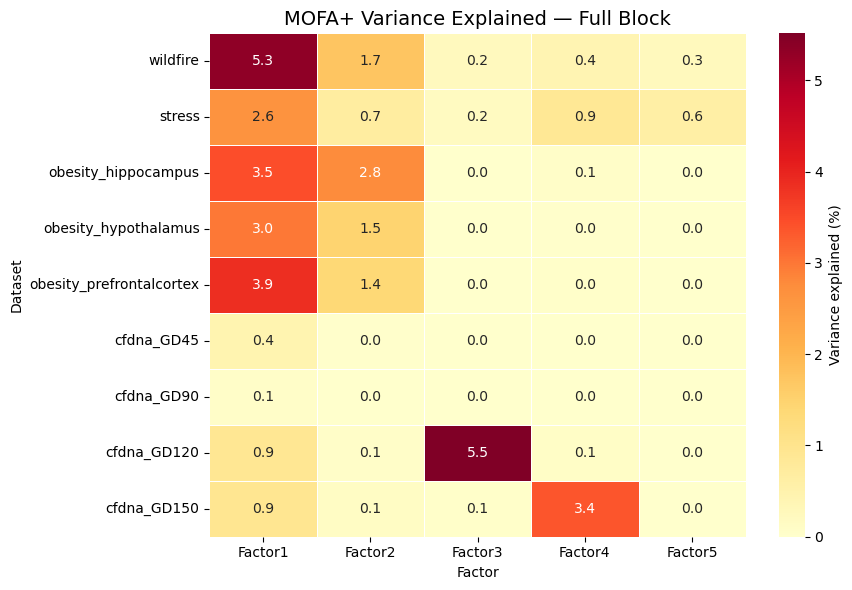

In [12]:
# Map group/view keys to real names
with h5py.File(mofa_file, 'r') as f:
    groups = [g.decode() if isinstance(g, bytes) else g for g in f['groups']['groups'][:]]
    views  = [v.decode() if isinstance(v, bytes) else v for v in f['views']['views'][:]]

# Single view: fullblock
region = 'fullblock'
r2_matrix = pd.DataFrame(r2_dict[region]).T
r2_matrix.index   = DATASETS
r2_matrix.columns = factor_cols[:r2_matrix.shape[1]]
r2_matrix = r2_matrix.clip(lower=0)

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(
    r2_matrix,
    annot=True, fmt='.1f',
    cmap='YlOrRd',
    vmin=0,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Variance explained (%)'}
)
ax.set_title('MOFA+ Variance Explained — Full Block', fontsize=14)
ax.set_xlabel('Factor')
ax.set_ylabel('Dataset')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'mofa_variance_explained.png', dpi=150, bbox_inches='tight')
plt.show()


In [14]:
print('factor_scores keys:', list(factor_scores.keys()))
print('all_labels keys:   ', list(all_labels.keys()))

# Check one sample
grp = 'wildfire'
print(f'\nfactor_scores[{grp}].index:', factor_scores[grp].index.tolist())
print(f'all_labels[{grp}].index:   ', all_labels[grp].index.tolist())

factor_scores keys: ['wildfire', 'stress', 'obesity_hippocampus', 'obesity_hypothalamus', 'obesity_prefrontalcortex', 'cfdna_GD45', 'cfdna_GD90', 'cfdna_GD120', 'cfdna_GD150']


NameError: name 'all_labels' is not defined

## Cell 7 — Factor Scores Coloured by Case/Control

For each dataset and each factor, we plot the factor scores split by case vs control. A factor that consistently separates case from control across multiple cohorts is the most important finding — it represents a shared methylation signature of early-life exposure.

**How to read these plots:**
- X-axis: factor score for each animal
- Groups: Control (blue) vs Case (red)
- If the distributions separate → this factor captures exposure-related variation in that cohort

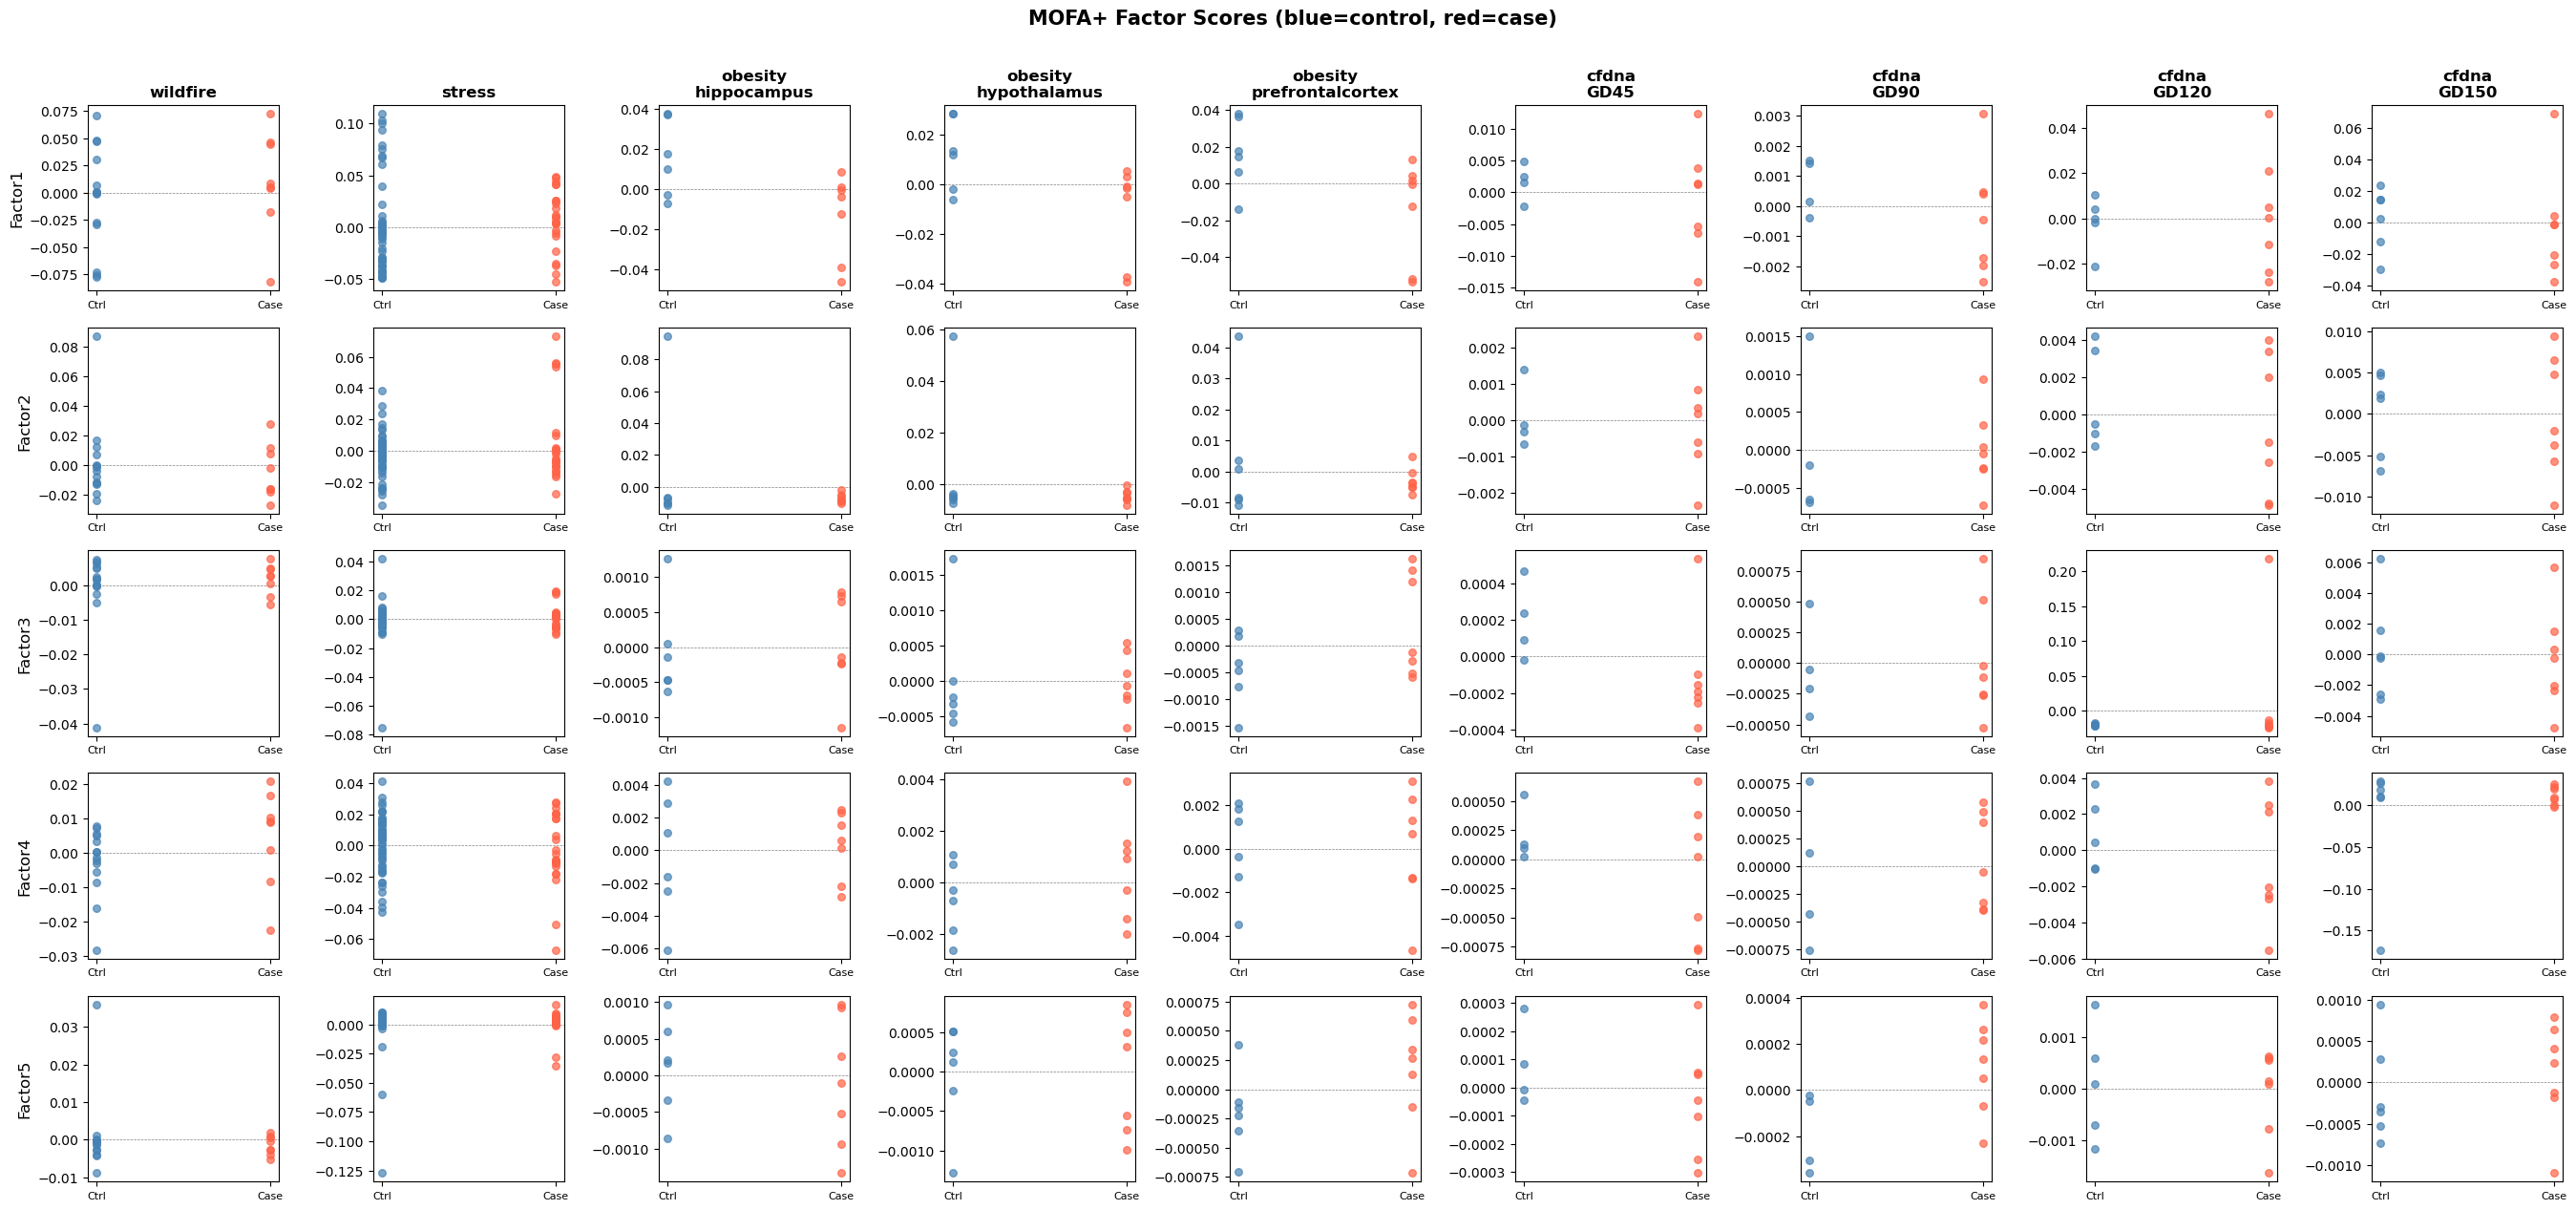

Saved: mofa_factor_scores.png


In [15]:
# ── Load labels for all datasets ─────────────────────────────────────
all_labels = {}
for ds in DATASETS:
    lpath = DATA_DIR / f'{ds}_labels.csv'
    if lpath.exists():
        lab = pd.read_csv(lpath, index_col='sample_id')
        lab.index = lab.index.astype(str)
        all_labels[ds] = lab['label']

# ── Factor score strip plots ──────────────────────────────────────────
n_groups_avail = len(factor_scores)
fig, axes = plt.subplots(
    N_FACTORS, n_groups_avail,
    figsize=(3 * n_groups_avail, 2.5 * N_FACTORS),
    squeeze=False
)

group_list = list(factor_scores.keys())
colors     = {0: 'steelblue', 1: 'tomato'}

for fi, factor in enumerate(factor_cols):
    for gi, grp in enumerate(group_list):
        ax    = axes[fi, gi]
        scores = factor_scores[grp][factor]

        if grp in all_labels:
            y = all_labels[grp].reindex(scores.index)
            for val, color in colors.items():
                mask = y == val
                ax.scatter(
                    [val] * mask.sum(),
                    scores[mask],
                    c=color, alpha=0.7, s=30, zorder=3
                )
            ax.set_xticks([0, 1])
            ax.set_xticklabels(['Ctrl', 'Case'], fontsize=8)
        else:
            ax.plot(scores.values, 'o', color='grey', ms=4)

        ax.set_ylabel(factor if gi == 0 else '', fontsize=12)
        ax.set_title(grp.replace('_', '\n') if fi == 0 else '', fontsize=12, fontweight="bold")
        ax.axhline(0, color='grey', lw=0.5, ls='--')

plt.suptitle('MOFA+ Factor Scores (blue=control, red=case)', fontsize=15, y=1.01, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'mofa_factor_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: mofa_factor_scores.png')

## Cell 8 — Top CpG Weights per Factor

The weights tell you **which CpGs drive each factor**. High positive weight = CpG is more methylated in samples with high factor scores. High negative weight = CpG is less methylated.

These are your candidate CpGs for the per-CpG meta-analysis in the next step. A CpG that has a high weight in a factor that also separates case/control is your primary hit.

In [16]:
# ── Top CpG weights per factor — fullblock view ─────────────────────
N_TOP = 10  # top CpGs to show per factor

region = 'fullblock'
if region in cpg_weights:
    W = cpg_weights[region]
    print(f'-- FULLBLOCK -- Top {N_TOP} CpGs per Factor --')
    for factor in factor_cols:
        top = W[factor].abs().sort_values(ascending=False).head(N_TOP)
        print(f'\n  {factor}:')
        for cpg, weight in top.items():
            direction = '+' if W.loc[cpg, factor] > 0 else '-'
            print(f'    {direction}{weight:.4f}  {cpg}')

# ── Save weights and scores ───────────────────────────────────────────
if region in cpg_weights:
    cpg_weights[region].to_csv(TABLES_DIR / 'mofa_weights_fullblock.csv')
    print(f'\nSaved: mofa_weights_fullblock.csv')

for grp in factor_scores:
    factor_scores[grp].to_csv(TABLES_DIR / f'mofa_scores_{grp}.csv')
print('Saved: mofa_scores_*.csv for all groups')


-- FULLBLOCK -- Top 10 CpGs per Factor --

  Factor1:
    +6.0966  feature1298_view0
    +5.9548  feature1304_view0
    +5.5890  feature1348_view0
    +5.5702  feature1132_view0
    +5.5466  feature1011_view0
    +5.5450  feature1525_view0
    +5.5369  feature1012_view0
    +5.3914  feature974_view0
    +5.2306  feature1342_view0
    +5.1287  feature878_view0

  Factor2:
    -6.5141  feature1620_view0
    -5.4534  feature2031_view0
    -5.2030  feature2207_view0
    -4.7029  feature1225_view0
    -4.5990  feature1981_view0
    -4.5653  feature1221_view0
    -4.5424  feature1940_view0
    -4.5381  feature1632_view0
    -4.4508  feature1612_view0
    -4.0756  feature900_view0

  Factor3:
    +4.0265  feature2637_view0
    +4.0124  feature2638_view0
    -4.0028  feature1131_view0
    +3.9445  feature2634_view0
    +3.8835  feature674_view0
    -3.7109  feature1686_view0
    -3.4823  feature370_view0
    -3.3716  feature2286_view0
    -3.3692  feature1664_view0
    -3.2974  feature128_view

## Cell 9 — Factor–Label Association (Mann-Whitney U test)

For each factor × group combination where we have case/control labels, we test whether factor scores differ significantly between groups using a Mann-Whitney U test (non-parametric, appropriate for small n).

**What to look for:**
- Low p-values (< 0.05) after correction = factor is associated with exposure in that cohort
- If the same factor is significant in 2+ cohorts → strongest evidence of a shared signature

**Bonferroni correction** divides the significance threshold by the number of tests. It is conservative (may miss real effects) but appropriate as a first pass.

In [17]:
print('factor_scores keys:', list(factor_scores.keys()))
print('all_labels keys:   ', list(all_labels.keys()))

factor_scores keys: ['wildfire', 'stress', 'obesity_hippocampus', 'obesity_hypothalamus', 'obesity_prefrontalcortex', 'cfdna_GD45', 'cfdna_GD90', 'cfdna_GD120', 'cfdna_GD150']
all_labels keys:    ['wildfire', 'stress', 'obesity_hippocampus', 'obesity_hypothalamus', 'obesity_prefrontalcortex', 'cfdna_GD45', 'cfdna_GD90', 'cfdna_GD120', 'cfdna_GD150']


In [18]:
from scipy.stats import mannwhitneyu

results = []
n_tests = 0

for factor in factor_cols:
    for grp in factor_scores:
        if grp not in all_labels:
            continue
        scores = factor_scores[grp][factor]
        y      = all_labels[grp].reindex(scores.index).dropna()
        scores = scores.reindex(y.index)

        ctrl = scores[y == 0]
        case = scores[y == 1]

        if len(ctrl) < 3 or len(case) < 3:
            # Too few samples for a meaningful test
            continue

        stat, pval = mannwhitneyu(ctrl, case, alternative='two-sided')
        n_tests   += 1
        results.append({
            'factor'       : factor,
            'dataset'      : grp,
            'n_ctrl'       : len(ctrl),
            'n_case'       : len(case),
            'median_ctrl'  : round(ctrl.median(), 4),
            'median_case'  : round(case.median(), 4),
            'MW_stat'      : round(stat, 2),
            'p_value'      : round(pval, 4),
        })

results_df = pd.DataFrame(results)

if results_df.empty:
    print('No tests ran — keys do not overlap between factor_scores and all_labels')
    print('factor_scores keys:', list(factor_scores.keys()))
    print('all_labels keys:   ', list(all_labels.keys()))
else:
    results_df = results_df.sort_values('p_value')
    alpha_corrected = 0.05 / max(n_tests, 1)
    results_df['significant_bonferroni'] = results_df['p_value'] < alpha_corrected

    print(f'Total tests: {n_tests}')
    print(f'Bonferroni threshold: p < {alpha_corrected:.4f}')
    print('\n── Top associations (sorted by p-value) ──')
    display(results_df.head(20))

    results_df.to_csv(TABLES_DIR / 'mofa_factor_label_association.csv', index=False)
    print('\nSaved: mofa_factor_label_association.csv')

Total tests: 45
Bonferroni threshold: p < 0.0011

── Top associations (sorted by p-value) ──


,factor,dataset,n_ctrl,n_case,median_ctrl,median_case,MW_stat,p_value,significant_bonferroni
4,Factor1,obesity_prefrontalcortex,6,7,0.0163,-0.0005,36.0,0.0350,False
1,Factor1,stress,52,24,-0.0101,0.0073,448.0,0.0499,False
2,Factor1,obesity_hippocampus,6,7,0.0137,-0.0040,35.0,0.0513,False
27,Factor4,wildfire,14,8,-0.0005,0.0090,29.0,0.0698,False
42,Factor5,cfdna_GD90,4,7,-0.0002,0.0001,4.0,0.0727,False
23,Factor3,cfdna_GD45,4,7,0.0002,-0.0002,24.0,0.0727,False
3,Factor1,obesity_hypothalamus,6,7,0.0129,-0.0016,33.0,0.1014,False
40,Factor5,obesity_prefrontalcortex,6,7,-0.0002,0.0003,11.0,0.1807,False
22,Factor3,obesity_prefrontalcortex,6,7,-0.0004,-0.0001,12.0,0.2343,False
30,Factor4,obesity_hypothalamus,6,7,-0.0005,0.0009,13.0,0.2949,False



Saved: mofa_factor_label_association.csv
